# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [2]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [3]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [4]:
import sklearn
print(sklearn.__version__)

1.4.1.post1


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [5]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [6]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [7]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

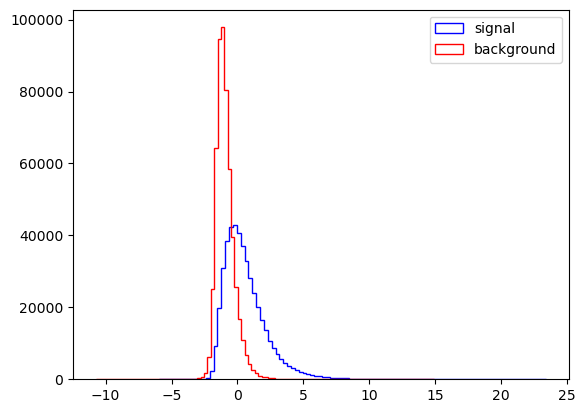

In [8]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

In [9]:
from sklearn import metrics

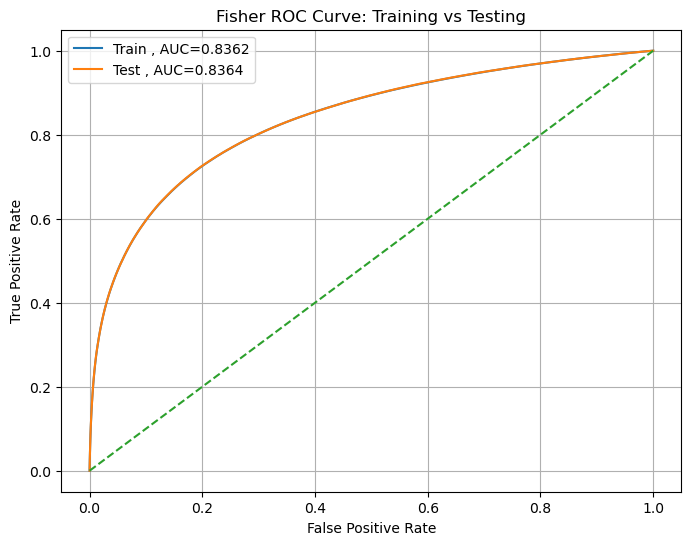

In [10]:
## for getting Fisher output for training and testing samples 
train_score=Fisher.decision_function(X_Train)
test_score=Fisher.decision_function(X_Test)

## for getting ROC curves
fpr_train ,tpr_train ,thr_train=metrics.roc_curve(y_Train ,train_score)
fpr_test ,tpr_test ,thr_test=metrics.roc_curve(y_Test ,test_score)

## area under the curve
auc_train=metrics.auc(fpr_train ,tpr_train)
auc_test=metrics.auc(fpr_test ,tpr_test)

## for plotting ROC curves on the same figure
plt.figure(figsize=(8,6))
plt.plot(fpr_train ,tpr_train ,label="Train , AUC="+str(round(auc_train,4)))
plt.plot(fpr_test ,tpr_test ,label="Test , AUC="+str(round(auc_test,4)))
plt.plot([0,1] ,[0,1] ,"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher ROC Curve: Training vs Testing")
plt.legend()
plt.grid()
plt.show()

In [11]:
## since the AUC values for both curves alre 0.8362 and 0.8364 and ROC curves are the same
## this shows that there is no significant bias 

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

In [12]:
print(VarNames)

['signal', 'l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 'l_2_phi', 'MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']


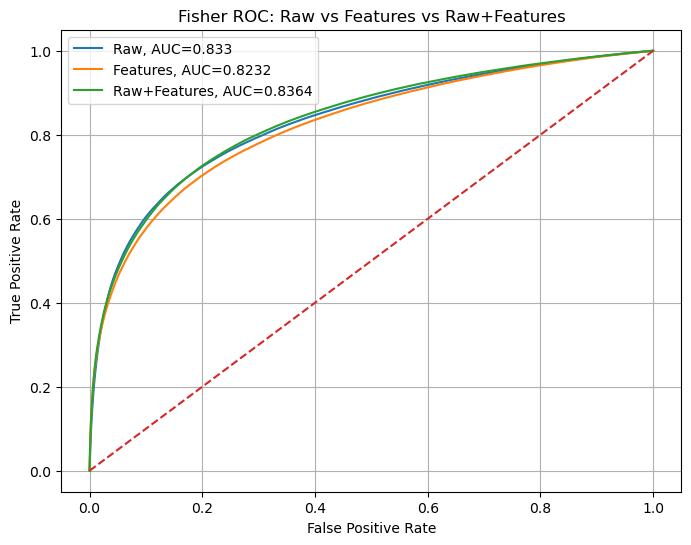

In [13]:
## from these,raw variables are:
RawVars=["l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi","MET","MET_phi"]
## engineered features are:
FeatureVars=["MET_rel","axial_MET","M_R","M_TR_2","R","MT2","S_R","M_Delta_R","dPhi_r_b","cos_theta_r1"]
## all inputs together
AllVars=RawVars+FeatureVars

## making 3 Fisher classifiers
Fisher_raw=DA.LinearDiscriminantAnalysis()
Fisher_feat=DA.LinearDiscriminantAnalysis()
Fisher_all=DA.LinearDiscriminantAnalysis()

## training each classifier
Fisher_raw.fit(Train_Sample[RawVars] ,y_Train)
Fisher_feat.fit(Train_Sample[FeatureVars] ,y_Train)
Fisher_all.fit(Train_Sample[AllVars] ,y_Train)

## getting classifier outputs on the test sample
score_raw=Fisher_raw.decision_function(Test_Sample[RawVars])
score_feat=Fisher_feat.decision_function(Test_Sample[FeatureVars])
score_all=Fisher_all.decision_function(Test_Sample[AllVars])

## ROC curves
fpr_raw ,tpr_raw ,thr_raw=metrics.roc_curve(y_Test ,score_raw)
fpr_feat ,tpr_feat ,thr_feat=metrics.roc_curve(y_Test ,score_feat)
fpr_all ,tpr_all ,thr_all=metrics.roc_curve(y_Test ,score_all)

## getting the area under each curve
auc_raw=metrics.auc(fpr_raw ,tpr_raw)
auc_feat=metrics.auc(fpr_feat ,tpr_feat)
auc_all=metrics.auc(fpr_all ,tpr_all)

## plotting all 3 ROC curves together
plt.figure(figsize=(8,6))
plt.plot(fpr_raw ,tpr_raw ,label="Raw, AUC="+str(round(auc_raw,4)))
plt.plot(fpr_feat ,tpr_feat ,label="Features, AUC="+str(round(auc_feat,4)))
plt.plot(fpr_all ,tpr_all ,label="Raw+Features, AUC="+str(round(auc_all,4)))
plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher ROC: Raw vs Features vs Raw+Features")
plt.legend()
plt.grid()
plt.show()

In [14]:
# the Raw+Features model gives the best performance (AUC = 0.8364)
# the Features model has the lowest performance (AUC = 0.8232)
# so using all variables together gives the best separation
# because it uses both the original measurements and the engineered features
# and in this case, the raw variables alone performed slightly better than
# the engineered features alone

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [15]:
## Ex.4a
## choosing 3 classifiers to choose from:
## 1. Logistic Regression
## 2. Decision Tree Classifier
## 3. Gradient Boosted Tree

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

## asked LLM if anything else was required here and it asked me to add this part below
## making the 3 classifier objects
LogReg=LogisticRegression(max_iter=500)
Tree=DecisionTreeClassifier(max_depth=5)
GB=GradientBoostingClassifier(n_estimators=50 ,max_depth=3)

X_Train_small=X_Train[:500000]
y_Train_small=y_Train[:500000]

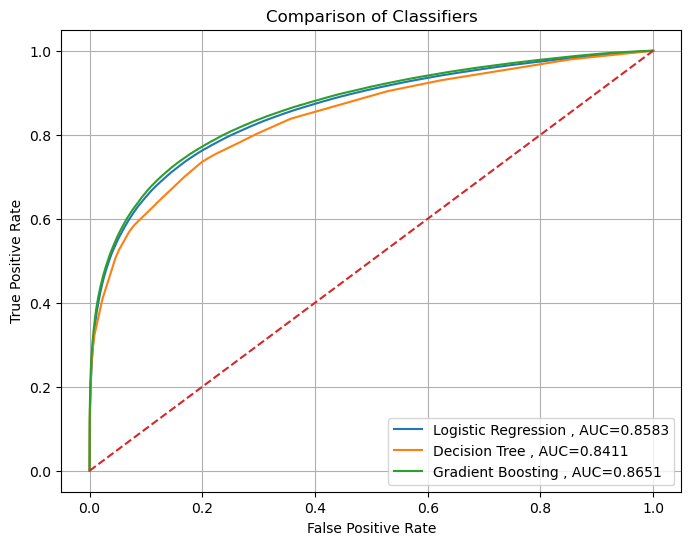

In [16]:
## Ex4.b

def compare_classifier(model ,name_text):
    ## fitting classifier on the smaller training data
    model.fit(X_Train_small ,y_Train_small)
    
    ## getting prediction scores on test data
    score=model.predict_proba(X_Test)[:,1]

    ## ROC curve
    fpr,tpr,thr=metrics.roc_curve(y_Test ,score)
    
    ## area under curve
    auc_val=metrics.auc(fpr ,tpr)

    ## plotting ROC curve
    plt.plot(fpr, tpr, label=name_text+" , AUC="+str(round(auc_val,4)))

## making one figure for all classifiers
plt.figure(figsize=(8,6))

## using the function on the 3 chosen classifiers
compare_classifier(LogReg ,"Logistic Regression")
compare_classifier(Tree ,"Decision Tree")
compare_classifier(GB ,"Gradient Boosting")

## reference line
plt.plot([0,1] ,[0,1] ,"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparison of Classifiers")
plt.legend()
plt.grid()
plt.show()

In [19]:
## this took a long time to load so I will try it with smaller train/test slices next time
X_Test_small=X_Test[:100000]
y_Test_small=y_Test[:100000]

## the Gradient Boosting classifier gives the best performance with AUC = 0.8651
## Logistic Regression comes next with AUC = 0.8583
## Decision Tree has lowest performance with AUC = 0.8411

## So the boosted tree method separates signal and background the best out of the three models tested
## Logistic Regression still performs well, showing that the data has some linear separation
## Whereas a single Decision Tree performs weaker because it is a much simpler model and can be less stable than boosted trees.

In [20]:
## Ex4.c

## using gradient boosting because its the best classifier from part b
BestModel=GB

## fitting it again on the same training sample used for the comparison
BestModel.fit(X_Train_small ,y_Train_small)

## getting classifier scores on the test sample
score=BestModel.predict_proba(X_Test_small)[:,1]

## separating scores into signal and background
score_sig=score[y_Test_small==1]
score_bkg=score[y_Test_small==0]

## the same scenarios used in Lab 5
scenarios=[(10,100),(100,1000),(1000,10000),(10000,100000)]

## making a set of cut values across the score range
xmin=min(np.min(score_sig),np.min(score_bkg))
xmax=max(np.max(score_sig),np.max(score_bkg))

cut_vals=np.linspace(xmin ,xmax ,200)

for Ns,Nb in scenarios:
    max_sigma=0
    best_cut=None

    ## scanning over all possible cut values
    for cut in cut_vals:
        # signal/background efficiency after the cut
        eps_s=np.sum(score_sig>cut)/len(score_sig)
        eps_b=np.sum(score_bkg>cut)/len(score_bkg)

        ## expected number of events after the cut
        Ns_new=eps_s*Ns
        Nb_new=eps_b*Nb

        ## significance
        if Ns_new+Nb_new>0:
            sigma=Ns_new/np.sqrt(Ns_new+Nb_new)
        else:
            sigma=0

        ## keeping the largest significance
        if sigma>max_sigma:
            max_sigma=sigma
            best_cut=cut

    print("Scenario: Ns=",Ns,", Nb=",Nb)
    print("Best cut =",round(best_cut,4))
    print("Max significance =",round(max_sigma,4))
    print()

Scenario: Ns= 10 , Nb= 100
Best cut = 0.7787
Max significance = 1.7529

Scenario: Ns= 100 , Nb= 1000
Best cut = 0.7787
Max significance = 5.5431

Scenario: Ns= 1000 , Nb= 10000
Best cut = 0.7787
Max significance = 17.5289

Scenario: Ns= 10000 , Nb= 100000
Best cut = 0.7787
Max significance = 55.4312



### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [21]:
## Ex 5.b
## Ex 5.b

from sklearn.metrics import roc_curve ,auc
from sklearn.metrics import precision_score ,recall_score ,f1_score ,accuracy_score
import pandas as pd
import numpy as np

## using the best model from 4c
BestModel=GB
BestModel.fit(X_Train_small ,y_Train_small)
score=BestModel.predict_proba(X_Test_small)[:,1]

## full ROC and AUC for the classifier
fpr ,tpr ,_=roc_curve(y_Test_small ,score)
roc_auc=auc(fpr ,tpr)
score_sig=score[y_Test_small==1]
score_bkg=score[y_Test_small==0]

## same scenarios from lab 5
scenarios=[(10,100),(100,1000),(1000,10000),(10000,100000)]\

rows=[]

for Ns ,Nb in scenarios:
    max_sigma=0
    best_cut=None
    best_eps_s=0
    best_eps_b=0

    ## scanning cuts to find maximal significance
    for cut in np.linspace(np.min(score),np.max(score),200):

        eps_s=np.sum(score_sig>cut)/len(score_sig)
        eps_b=np.sum(score_bkg>cut)/len(score_bkg)

        Ns_new=eps_s*Ns
        Nb_new=eps_b*Nb

        if Ns_new+Nb_new>0:
            sigma=Ns_new/np.sqrt(Ns_new+Nb_new)
        else:
            sigma=0

        if sigma>max_sigma:
            max_sigma=sigma
            best_cut=cut
            best_eps_s=eps_s
            best_eps_b=eps_b

    ## expected counts after applying the best cut
    TP=int(round(best_eps_s*Ns))
    FN=int(round(Ns-TP))
    FP=int(round(best_eps_b*Nb))
    TN=int(round(Nb-FP))

    ## building y_true and y_pred so sklearn can compute the metrics
    y_true=np.array([1]*Ns + [0]*Nb)
    y_pred=np.array([1]*TP + [0]*FN + [1]*FP + [0]*TN)

    ## metrics
    precision=precision_score(y_true ,y_pred)
    recall=recall_score(y_true ,y_pred)
    f1=f1_score(y_true ,y_pred)
    accuracy=accuracy_score(y_true ,y_pred)

    ## TPR is the same as recall
    ## FPR = FP / (FP + TN)
    if FP+TN>0:
        fpr_val=FP/(FP+TN)
    else:
        fpr_val=0

    rows.append([Ns,Nb, round(best_cut,4), round(best_eps_s,4), round(best_eps_b,4) ,round(best_eps_s,4) ,
        round(fpr_val,4) ,round(roc_auc,4) ,round(precision,4) ,round(recall,4) ,round(f1,4) ,
        round(accuracy,4) ,round(max_sigma,4)])

# making a table
results=pd.DataFrame(rows ,columns=["Ns" ,"Nb" ,"Best Cut" ,"Signal Eff" ,"Background Eff" ,"TPR" ,"FPR" ,"AUC", 
                                    "Precision" ,"Recall","F1 Score" ,"Accuracy" ,"Max Significance"])

results

,Ns,Nb,Best Cut,Signal Eff,Background Eff,TPR,FPR,AUC,Precision,Recall,F1 Score,Accuracy,Max Significance
0,10,100,0.7787,0.4591,0.0227,0.4591,0.0200,0.8637,0.7143,0.5000,0.5882,0.9364,1.7529
1,100,1000,0.7787,0.4591,0.0227,0.4591,0.0230,0.8637,0.6667,0.4600,0.5444,0.9300,5.5431
2,1000,10000,0.7787,0.4591,0.0227,0.4591,0.0227,0.8637,0.6691,0.4590,0.5445,0.9302,17.5289
3,10000,100000,0.7787,0.4591,0.0227,0.4591,0.0227,0.8637,0.6692,0.4591,0.5446,0.9302,55.4312


In [22]:
## I used the best classifier from 4c and scanned over the classifier score to find the cut that gives the maximal significance for each scenario.
## For each best cut I used sklearn metrics tools to compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and Accuracy
## The AUC comes from the full ROC curve of the classifier
## and metrics are computed at the cut that gives maximal significance.